In [1]:
# making somewhat cleaned-up versions of figures for figure 3 + related supplementary figures; 
# at the cell-line-level only for now

In [2]:
import math
import random
import re
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib import cm
import matplotlib 
%matplotlib inline

In [3]:
import matplotlib.font_manager
matplotlib.font_manager.findSystemFonts(fontpaths=None, fontext='ttf');

font = matplotlib.font_manager.FontProperties(fname='/System/Library/Fonts/Helvetica.ttc')

In [4]:
# cell line IDs w/o spike-ins 2, 3, mt4-2D
clIDs = ['GATC', 'AAGG', 'ACAC', 'ACCT', 'ACGA', 'ACTG', 'AGAG', 'AGCA', 'AGGT', 'AGTC', 'ATCG', 'ATGC', 'CAAC', 'CACT', 'CAGA', 'CATG', 'CCAA', 'CCTT', 'CGAT', 'CGTA', 'CTGT', 'CTTC', 'GAAG', 'GCAT', 'GCTA', 'GGAA', 'GGTT', 'GTAC', 'GTGA', 'GTTG', 'TCCA', 'TGAC', 'TTCC', 'TTGG']
cell_line_labels = ['Spike-in 1', '7160c2', 'FC1199', '6694c2', '7160c5', 'BF857', 'BF1987', 'Panc02', '0688M', 'FC1245', 'BF4326', 'BF2117', '6419c5', 'BF4326', 'KPC960', '0755P', 'BF1836', 'BF2014', 'BF5960', '6499c4', '6422c5', 'FC1245', 'KPC-JH', 'KPC960', 'BF2153', 'KC6141', 'mT3-2D', 'mT5-2D', '0764P', '6421c2', '0755A', '2838c3', 'FC1242', 'KPC961']
clID__label = dict(zip(clIDs, cell_line_labels))

In [5]:
# see below
clID__color = {'AGGT': (0.7568627450980392, 0.24313725490196078, 0.1803921568627451, 1.0),
               'AGCA': (0.7712572087658592, 0.2597462514417531, 0.19663206459054208, 1.0),
               'CTTC': (0.9545098039215686, 0.5642445213379469, 0.48705882352941177, 1.0),
               'AGTC': (0.9592156862745098, 0.5794694348327566, 0.5011764705882353, 1.0),
               'ATCG': (0.973517877739331, 0.6467358708189158, 0.5638292964244522, 1.0),
               'GAAG': (0.9646597462514417, 0.6810611303344867, 0.5964936562860439, 1.0),
               'CACT': (0.9498961937716263, 0.7382698961937716, 0.6509342560553634, 1.0),
               'ACCT': (0.9498961937716263, 0.7382698961937716, 0.6509342560553634, 1.0),
               'CCTT': (0.9439907727797, 0.7611534025374858, 0.6727104959630913, 1.0),
               'CATG': (0.9351326412918108, 0.7954786620530565, 0.7053748558246828, 1.0),
               'GGAA': (0.9174163783160323, 0.8641291810841983, 0.7707035755478662, 1.0),
               'ACAC': (0.9144636678200692, 0.8755709342560554, 0.7815916955017301, 1.0),
               'GTTG': (0.8975778546712803, 0.8717416378316032, 0.7831603229527104, 1.0),
               'AGAG': (0.8975778546712803, 0.8717416378316032, 0.7831603229527104, 1.0),
               'TTGG': (0.8265282583621683, 0.8423068050749711, 0.7780853517877739, 1.0),
               'TCCA': (0.7748558246828141, 0.8208996539792387, 0.77439446366782, 1.0),
               'CTGT': (0.768396770472895, 0.8182237600922722, 0.7739331026528258, 1.0),
               'TTCC': (0.7361014994232987, 0.8048442906574395, 0.7716262975778546, 1.0),
               'CAGA': (0.7296424452133794, 0.8021683967704729, 0.7711649365628604, 1.0),
               'GCAT': (0.7167243367935409, 0.7968166089965397, 0.7702422145328719, 1.0),
               'CGTA': (0.6521337946943483, 0.7700576701268742, 0.7656286043829296, 1.0),
               'GGTT': (0.6328489042675893, 0.7613840830449826, 0.7628604382929642, 1.0),
               'ACGA': (0.6264821222606689, 0.7580622837370241, 0.7610149942329872, 1.0),
               'AAGG': (0.5564475201845444, 0.7215224913494809, 0.740715109573241, 1.0),
               'GTAC': (0.4800461361014994, 0.6816608996539792, 0.7185697808535179, 1.0),
               'CGAT': (0.4609457900807381, 0.6716955017301037, 0.7130334486735871, 1.0),
               'GCTA': (0.44184544405997694, 0.6617301038062283, 0.7074971164936563, 1.0),
               'CAAC': (0.44184544405997694, 0.6617301038062283, 0.7074971164936563, 1.0),
               'TGAC': (0.40364475201845446, 0.6417993079584775, 0.6964244521337947, 1.0),
               'ATGC': (0.39727797001153403, 0.638477508650519, 0.6945790080738178, 1.0),
               'ACTG': (0.3845444059976932, 0.6318339100346021, 0.6908881199538639, 1.0),
               'GTGA': (0.1734717416378316, 0.5384083044982699, 0.615686274509804, 1.0),
               'CCAA': (0.10408304498269896, 0.5081430219146482, 0.5905882352941176, 1.0)}

In [6]:
# pre-processed data

metadata = pd.read_csv('/Users/alyulina/Projects/Cancer/Data/metadata.csv', index_col='sample id') # all sequencing samples
read_counts_by_cell_line = pd.read_csv('/Users/alyulina/Projects/Cancer/Data/cell-line_read_counts.csv', index_col='clID')
cell_counts_by_cell_line = pd.read_csv('/Users/alyulina/Projects/Cancer/Data/cell-line_cell_counts.csv', index_col='clID')


### Some helpful functions

In [7]:
def bootstrap(samples, B=10000, 
              clIDs=clIDs, 
              read_counts=read_counts_by_cell_line,
              cell_counts=cell_counts_by_cell_line, 
              metadata=metadata):
    
    clID__distr = {}  # bootstrap distributions of n_t / n_0
    clID__exp_avg_relative_to_mean = {} # weighted average across mice relative to average across all cell lines
    clID__exp_err = {} # 0.95 ci of the above
    
    n_samples = len(samples)
    experiment = metadata.loc[[s for s in samples if ':' not in s], 'experiment'].iloc[0]    
    pre_injection = metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == experiment)]

    # precompute pre-injection cell counts for each clID first,
    # by finding thir fractions and multiplying by the total number of cells injected
    n_0_dict = {clID: np.mean([read_counts[sample_id][clID] / sum(read_counts[sample_id][1:]) * pre_injection['initial number of cells'].mean() 
                               for sample_id in pre_injection.index.tolist()]) for clID in clIDs if clID != 'GATC'}

    # bootstrapping mices to make one big mouse
    # this is equivalent to weighting each sample by the total number of cells and taking the avg
    avgs = []
    for clID, n_0 in n_0_dict.items():
        
        mouse_i_samples = np.random.choice(samples, size=(B, n_samples), replace=True)
        n_t = np.array([sum(cell_counts[mouse][clID] for mouse in mouse_i) for mouse_i in mouse_i_samples])
        clID__distr[clID] = n_t / (n_0 * B)
        avgs.append(clID__distr[clID])
        
    mean_across_cell_lines = np.mean(avgs)

    for clID in clIDs:
        if clID == 'GATC':
            continue
        y = np.mean(clID__distr[clID])
    
        ci_upper = np.percentile(clID__distr[clID], 97.5)
        ci_lower = np.percentile(clID__distr[clID], 2.5)
        clID__exp_err[clID] = [(y - ci_lower) / mean_across_cell_lines, (ci_upper - y) / mean_across_cell_lines]
        clID__exp_avg_relative_to_mean[clID] = y / mean_across_cell_lines
    
    clIDs_sorted = [y[0] for y in sorted([[x, clID__exp_avg_relative_to_mean[x]] for x in clIDs if x != 'GATC'], key = lambda x: x[-1], reverse=True)]

    return clID__distr, clID__exp_avg_relative_to_mean, clID__exp_err, clIDs_sorted

    

In [8]:
def metric_bar_plot(clIDs_ordered, clID__y, clID__err, ytitle='metric', # metric (to be displayed on y-axis)
                    clID__color=clID__color, clID__label=clID__label, # colors / labels
                    ylims=[1e-2, 1e1], yticks=[1e-2, 1e-1, 1e0, 1e1], ylabels=['0.01', '0.1', '1', '10']):
    """
    Makes a bar plot with some kind of metric with on a log-scale y-axis, and cell lines on the x-axis.
    
    Parameters:
    
    - clIDs_ordered: List of cell line IDs, ordered.
    - clID__y: Dictionary with cell line IDs as keys and metric values as values (e.g. 'AAGT': 0.02).
    - clID__err: Dictionary with cell line IDs as keys and -/+ errors as values (e.g. 'AAGT': [0.01, 0.01]).
    
    - clID__color: Dictionary mapping cell line IDs to colors.
    - clID__label: Dictionary mapping cell line IDs to label names.
    
    - ylims: Limits for the y-axis.
    - yticks: Locations for y-axis ticks.
    - ylabels: Locations for y-axis tick labels.
    """
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['bottom'].set_position(('axes', -0.025))
    ax.spines['left'].set_position(('axes', -0.025))

    heights, bottoms, ys, errs, cs = [], [], [], [[], []], []
    
    for i in clIDs_ordered:
        cs.append(clID__color[i])
        ys.append(clID__y[i])
        errs[0].append(clID__err[i][0])
        errs[1].append(clID__err[i][1])
        
        if clID__y[i] > 1:
            bottoms.append(1)
            heights.append(clID__y[i] - 1)
        else:
            bottoms.append(clID__y[i])
            heights.append(1 - clID__y[i])

    ax.bar(range(len(clIDs_ordered)), heights, width=0.8, bottom=bottoms, color=cs, 
           edgecolor='black', linewidth=0.75, clip_on=False)
    
    ax.errorbar(range(len(clIDs_ordered)), ys, yerr=errs, color='black', linewidth=0.75, 
                alpha=1, zorder=1, ls='none', clip_on=False)

    ax.set_yscale('log')
    ax.minorticks_off()
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, size=12)
    ax.set_ylim(ylims[0], ylims[1])

    ax.set_xlim(0, len(clIDs_ordered) - 1)
    ax.set_xticks(range(len(clIDs_ordered)))
    ax.set_xticklabels([clID__label[x].replace('_', ' ') for x in clIDs_ordered], size=12, rotation=90)

    ax.set_ylabel(ytitle, fontsize=14, labelpad=6)

    return ax

In [9]:
def comparison_scatter_plot(clIDs, # always exclude spike-in, sometimes Panc02 as well
                            clID__x, clID__xerr, 
                            clID__y, clID__yerr, 
                            xtitle='metric', ytitle='metric', # metric (to be displayed on y-axis)
                            clID__color=clID__color, clID__label=clID__label, # colors / labels
                            lims=[1e-3, 1e3], ticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3], labels=['0.001', '0.01', '0.1', '1', '10', '100', '1000']):
    """
    Makes a scatter plot comparing two experiments,
    including Spearman and Pearson correlation coefficients with p-values.
    
    Makes a bar plot with some kind of metric with on a log-scale y-axis, and cell lines on the x-axis.
    
    Parameters:
    
    - clIDs: List of cell line IDs, in any order; all of these cell lines will be used to compute correlations.
    - clID__x, clID__y: Dictionary with cell line IDs as keys and metric values as values (e.g. 'AAGT': 0.02).
    - clID__xerr, clID__yerr: Dictionary with cell line IDs as keys and -/+ errors as values (e.g. 'AAGT': [0.01, 0.01]).
    
    - clID__color: Dictionary mapping cell line IDs to colors.
    - clID__label: Dictionary mapping cell line IDs to label names.
    
    - lims: Limits for the x- and y-axis.
    - ticks: Locations for x- and y-axis ticks.
    - labels: Locations for x- and y-axis tick labels.
    """

    fig, ax = plt.subplots(figsize=(4, 4))
    
    xs = [clID__x[x] for x in clIDs]
    ys = [clID__y[y] for y in clIDs]
    
    ax.scatter(xs, ys, color=[clID__color[z] for z in clIDs], s=80, edgecolor='black', linewidth=0.75, alpha=1, zorder=1)
    ax.errorbar(xs, ys, xerr=[[clID__xerr[x][0] for x in clIDs], [clID__xerr[x][1] for x in clIDs]], yerr=[[clID__yerr[y][0] for y in clIDs], [clID__yerr[y][1] for y in clIDs]], color='black', linewidth=0.75, ls='none', zorder=-2)

    ax.plot(lims, lims, color='#c1c1c1', zorder=-3)  # diagonal Line
    ax.plot(lims, [1e0, 1e0], color='#c1c1c1', alpha=0.3, zorder=-3)  # horizontal Line
    ax.plot([1e0, 1e0], lims, color='#c1c1c1', alpha=0.3, zorder=-3)  # vertical Line


    spearmans_rho, spearmans_pval = sp.stats.spearmanr(xs, ys)  # rank correlation coefficient and p-value
    pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value
    ax.text(2 * lims[0], 0.3 * lims[1], f'ρ = {spearmans_rho:.2f}, p = {spearmans_pval:.0e}', size=10)
    ax.text(2 * lims[0], 0.15 * lims[1], f'r = {pearsons_r:.2f}, p = {pearsons_pval:.0e}', size=10)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.minorticks_off()
    ax.set_xlim(lims[0], lims[1])
    ax.set_ylim(lims[0], lims[1])
    ax.set_xticks(ticks, labels, size=12)
    ax.set_yticks(ticks, labels, size=12)

    ax.set_xlabel(xtitle, fontsize=14, labelpad=6)
    ax.set_ylabel(ytitle, fontsize=14, labelpad=6)
        
    return ax


### Organ tropism plots (second exp.)

In [113]:
what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [114]:
what = ['2', 20, 'C57B6/129S F1', 'pancreas']
samples_pancreas = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['tissue'] == what[3])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [115]:
what = ['2', 20, 'C57B6/129S F1', 'liver']
samples_liver = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['tissue'] == what[3])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [116]:
clID__in_vivo_exp, clID__in_vivo_exp_avg_relative_to_mean, clID__in_vivo_exp_err, clIDs_sorted = bootstrap(samples)

clID__in_vivo_exp_pancreas, clID__in_vivo_exp_avg_pancreas_relative_to_mean, clID__in_vivo_exp_pancreas_err, clIDs_sorted_pancreas = bootstrap(samples_pancreas)
clID__in_vivo_exp_liver, clID__in_vivo_exp_avg_liver_relative_to_mean, clID__in_vivo_exp_liver_err, clIDs_sorted_liver = bootstrap(samples_liver)

excluded: Spike-in 1
excluded: Panc02


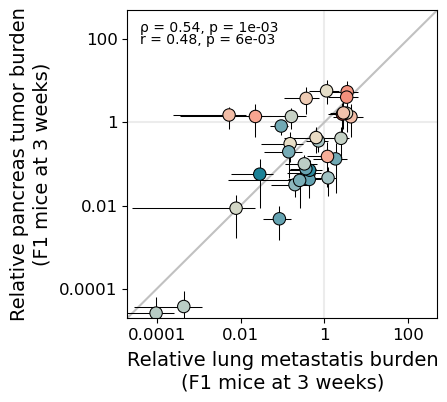

In [117]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

ax = comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                              clID__x=clID__in_vivo_exp_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_err,
                              clID__y=clID__in_vivo_exp_avg_pancreas_relative_to_mean, clID__yerr=clID__in_vivo_exp_pancreas_err,
                              xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative pancreas tumor burden\n(F1 mice at 3 weeks)',
                              lims=[2e-5, 0.5e3], ticks=[1e-4, 1e-2, 1e0, 1e2], labels=['0.0001', '0.01', '1', '100'])

#plt.savefig('../../../Figures/fig4/fig4_relative_in_vivo_exp_vs_pancreas_exp2.pdf', dpi=300, bbox_inches='tight')  

excluded: Spike-in 1
excluded: Panc02


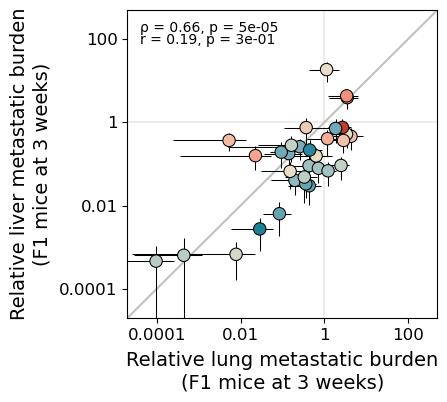

In [118]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

ax = comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                              clID__x=clID__in_vivo_exp_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_err,
                              clID__y=clID__in_vivo_exp_avg_liver_relative_to_mean, clID__yerr=clID__in_vivo_exp_liver_err,
                              xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative liver metastatic burden\n(F1 mice at 3 weeks)',
                              lims=[2e-5, 0.5e3], ticks=[1e-4, 1e-2, 1e0, 1e2], labels=['0.0001', '0.01', '1', '100'])

#plt.savefig('../../../Figures/fig4/fig4_relative_in_vivo_exp_vs_liver_exp2.pdf', dpi=300, bbox_inches='tight')  

excluded: Spike-in 1
excluded: Panc02
excluded: KPC960
excluded: KPC960
excluded: BF4326
excluded: BF4326


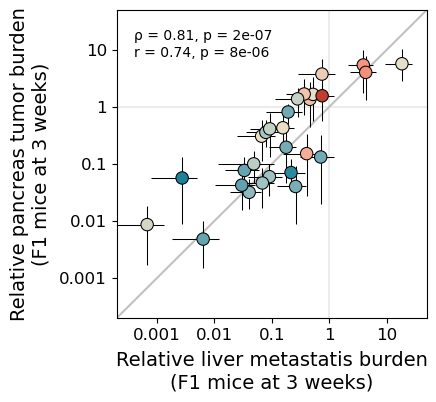

In [119]:
excluded_clIDs = ['GATC', 'AGCA', 'CAGA', 'GCAT', 'ATCG', 'CACT']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

ax = comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                              clID__x=clID__in_vivo_exp_avg_liver_relative_to_mean, clID__xerr=clID__in_vivo_exp_liver_err,
                              clID__y=clID__in_vivo_exp_avg_pancreas_relative_to_mean, clID__yerr=clID__in_vivo_exp_pancreas_err,
                              xtitle='Relative liver metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative pancreas tumor burden\n(F1 mice at 3 weeks)',
                              lims=[2e-4, 0.5e2], ticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1], labels=['0.001', '0.01', '0.1', '1', '10'])

#plt.savefig('../../../Figures/fig4/fig4_relative_exp_liver_vs_pancreas_exp2.pdf', dpi=300, bbox_inches='tight')  

excluded: Spike-in 1
excluded: Panc02
excluded: KPC960
excluded: KPC960
excluded: BF4326
excluded: BF4326


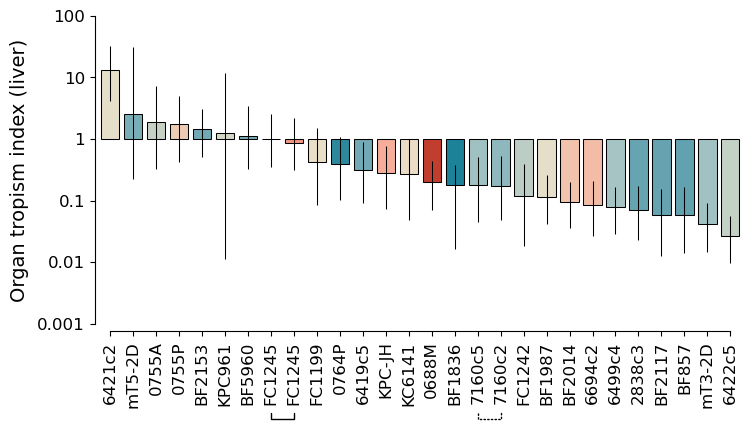

In [120]:
excluded_clIDs = ['GATC', 'AGCA', 'CAGA', 'GCAT', 'ATCG', 'CACT']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

# calculating organ tropism index: liver
clID__liver_index_distr = {}
clID__liver_index_avg_relative_to_mean = {}
clID__liver_index_err = {}
for clID in clIDs:
    if clID in excluded_clIDs:
        continue
    clID__liver_index_distr[clID] = clID__in_vivo_exp_liver[clID] / (clID__in_vivo_exp[clID] + 1e-12)
    
y_mean = np.mean([np.mean(clID__liver_index_distr[clID]) for clID in clIDs if clID not in excluded_clIDs])

for clID in clIDs:
    if clID in excluded_clIDs:
        continue
    y = np.mean(clID__liver_index_distr[clID])
    
    ci_upper = np.percentile(clID__liver_index_distr[clID], 97.5)
    ci_lower = np.percentile(clID__liver_index_distr[clID], 2.5)
    clID__liver_index_err[clID] = [(y - ci_lower) / y_mean, (ci_upper - y) / y_mean]
    clID__liver_index_avg_relative_to_mean[clID] = y / y_mean
    
clIDs_sorted = [y[0] for y in sorted([[x, clID__liver_index_avg_relative_to_mean[x]] for x in clIDs if x not in excluded_clIDs], key = lambda x: x[-1], reverse=True)]

ax = metric_bar_plot(clIDs_sorted, clID__liver_index_avg_relative_to_mean, clID__liver_index_err, 
                     ytitle='Organ tropism index (liver)', 
                     ylims=[1e-3, 1e2], yticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], ylabels=['0.001', '0.01', '0.1', '1', '10', '100'])

ax.annotate('', xy=(7, 0.00004), xycoords='data', xytext=(8, 0.00004), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.4'), 
            annotation_clip=False);

ax.annotate('', xy=(16, 0.00004), xycoords='data', xytext=(17, 0.00004), textcoords='data',
            arrowprops=dict(arrowstyle='-', linestyle=':', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.4'), 
            annotation_clip=False);

#plt.savefig('../../../Figures/fig4/fig4_liver_index.pdf', dpi=300, bbox_inches='tight')  


excluded: Spike-in 1
excluded: Panc02
excluded: KPC960
excluded: KPC960
excluded: BF4326
excluded: BF4326


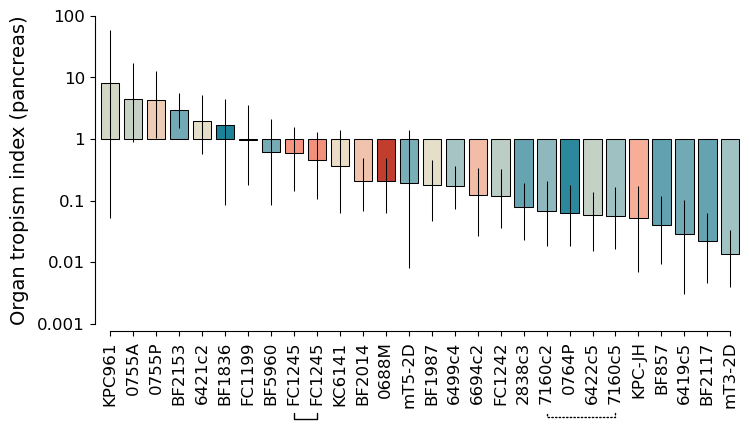

In [121]:
excluded_clIDs = ['GATC', 'AGCA', 'CAGA', 'GCAT', 'ATCG', 'CACT']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

# calculating organ tropism index: pancreas
clID__pancreas_index_distr = {}
clID__pancreas_index_avg_relative_to_mean = {}
clID__pancreas_index_err = {}
for clID in clIDs:
    if clID in excluded_clIDs:
        continue
    clID__pancreas_index_distr[clID] = clID__in_vivo_exp_pancreas[clID] / clID__in_vivo_exp[clID]
    
y_mean = np.mean([np.mean(clID__pancreas_index_distr[clID]) for clID in clIDs if clID not in excluded_clIDs])

for clID in clIDs:
    if clID in excluded_clIDs:
        continue
    y = np.mean(clID__pancreas_index_distr[clID])
    
    ci_upper = np.percentile(clID__pancreas_index_distr[clID], 97.5)
    ci_lower = np.percentile(clID__pancreas_index_distr[clID], 2.5)
    clID__pancreas_index_err[clID] = [(y - ci_lower) / y_mean, (ci_upper - y) / y_mean]
    clID__pancreas_index_avg_relative_to_mean[clID] = y / y_mean
    
clIDs_sorted = [y[0] for y in sorted([[x, clID__pancreas_index_avg_relative_to_mean[x]] for x in clIDs if x not in excluded_clIDs], key = lambda x: x[-1], reverse=True)]

ax = metric_bar_plot(clIDs_sorted, clID__pancreas_index_avg_relative_to_mean, clID__pancreas_index_err, 
                     ytitle='Organ tropism index (pancreas)', 
                     ylims=[1e-3, 1e2], yticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], ylabels=['0.001', '0.01', '0.1', '1', '10', '100'])

ax.annotate('', xy=(8, 0.00004), xycoords='data', xytext=(9, 0.00004), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.4'), 
            annotation_clip=False);

ax.annotate('', xy=(19, 0.00004), xycoords='data', xytext=(22, 0.00004), textcoords='data',
            arrowprops=dict(arrowstyle='-', linestyle=':', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.1'), 
            annotation_clip=False);

#plt.savefig('../../../Figures/fig4/fig4_pancreas_index.pdf', dpi=300, bbox_inches='tight')  


### Supplementary figures: immune rejection plots

In [122]:
# making a list of 3w F1 iv lung samples from exp. two
what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [123]:
# making a list of 3w Rag1 iv lung samples from exp. two
what = ['2', 20, 'Rag1-/-', 'intravenous', 'lung']
samples_wo_immune_system = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['injection method'] == what[3]) & 
                                   (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [124]:
clID__in_vivo_exp, clID__in_vivo_exp_avg_relative_to_mean, clID__in_vivo_exp_err, clIDs_sorted = bootstrap(samples)
clID__in_vivo_exp_wo_immune_system, clID__in_vivo_exp_avg_wo_immune_system_relative_to_mean, clID__in_vivo_exp_wo_immune_system_err, clIDs_sorted_wo_immune_system = bootstrap(samples_wo_immune_system)


excluded: Spike-in 1
excluded: Panc02


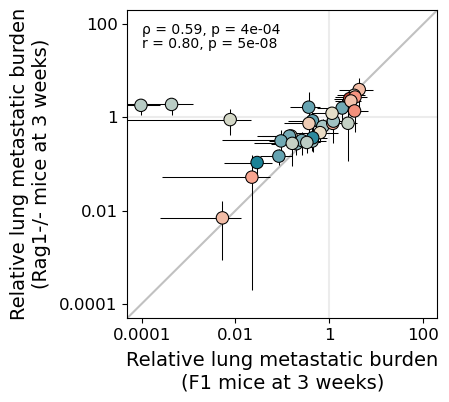

In [127]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                              clID__x=clID__in_vivo_exp_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_err,
                              clID__y=clID__in_vivo_exp_avg_wo_immune_system_relative_to_mean, clID__yerr=clID__in_vivo_exp_wo_immune_system_err,
                              xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative lung metastatic burden\n(Rag1-/- mice at 3 weeks)',
                              lims=[5e-5, 2e2], ticks=[1e-4, 1e-2, 1e0, 1e2], labels=['0.0001', '0.01', '1', '100'])

#plt.savefig('../../../Figures/fig4/fig4_si_relative_in_vivo_exp_w_and_wo_immune_system_exp2.pdf', dpi=300, bbox_inches='tight')  

In [128]:
excluded_clIDs = ['GATC', 'AGCA', 'CAGA', 'GCAT', 'ATCG', 'CACT']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

# calculating immune rejection index
clID__immune_rejection_index_distr = {}
clID__immune_rejection_index_avg_relative_to_mean = {}
clID__immune_rejection_index_err = {}
for clID in clIDs:
    if clID in excluded_clIDs:
        continue
    clID__immune_rejection_index_distr[clID] = clID__in_vivo_exp_wo_immune_system[clID] / clID__in_vivo_exp[clID]
    
y_mean = np.mean([np.mean(clID__immune_rejection_index_distr[clID]) for clID in clIDs if clID not in excluded_clIDs])

for clID in clIDs:
    if clID in excluded_clIDs:
        continue
    y = np.mean(clID__immune_rejection_index_distr[clID])
    
    ci_upper = np.percentile(clID__immune_rejection_index_distr[clID], 97.5)
    ci_lower = np.percentile(clID__immune_rejection_index_distr[clID], 2.5)
    clID__immune_rejection_index_err[clID] = [(y - ci_lower) / y_mean, (ci_upper - y) / y_mean]
    clID__immune_rejection_index_avg_relative_to_mean[clID] = y / y_mean
    
clIDs_sorted_immune_rejection_index = [y[0] for y in sorted([[x, clID__immune_rejection_index_avg_relative_to_mean[x]] for x in clIDs if x not in excluded_clIDs], key = lambda x: x[-1], reverse=True)]

excluded: Spike-in 1
excluded: Panc02
excluded: KPC960
excluded: KPC960
excluded: BF4326
excluded: BF4326


excluded: Spike-in 1
excluded: Panc02
excluded: KPC960
excluded: KPC960
excluded: BF4326
excluded: BF4326


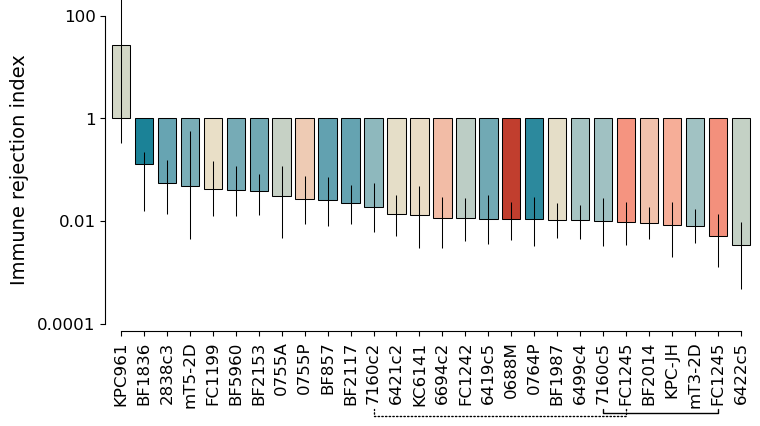

In [129]:
excluded_clIDs = ['GATC', 'AGCA', 'CAGA', 'GCAT', 'ATCG', 'CACT']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = metric_bar_plot(clIDs_sorted_immune_rejection_index, clID__immune_rejection_index_avg_relative_to_mean, clID__immune_rejection_index_err, 
                     ytitle='Immune rejection index', 
                     ylims=[1e-4, 1e2], yticks=[1e-4, 1e-2, 1e0, 1e2], ylabels=['0.0001', '0.01', '1', '100'])

ax.annotate('', xy=(21, 0.0000025), xycoords='data', xytext=(26, 0.0000025), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.06'), 
            annotation_clip=False);

ax.annotate('', xy=(11, 0.0000025), xycoords='data', xytext=(22, 0.0000025), textcoords='data',
            arrowprops=dict(arrowstyle='-', linestyle=':', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.04'), 
            annotation_clip=False);

#plt.savefig('../../../Figures/fig4/fig4_si_immune_rejection_index_exp2.pdf', dpi=300, bbox_inches='tight')  


### Supplementary figures: in vitro comparisons

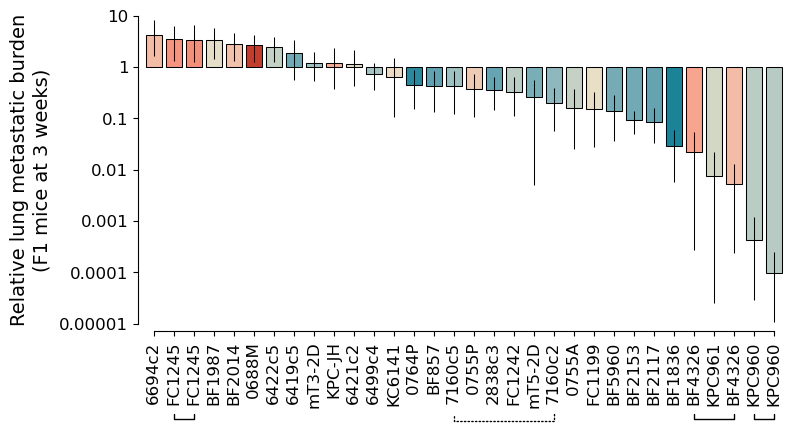

In [130]:
ax = metric_bar_plot(clIDs_sorted[:-1], clID__in_vivo_exp_avg_relative_to_mean, clID__in_vivo_exp_err, 
                     ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', 
                     ylims=[1e-5, 1e1], yticks=[1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1], ylabels=['0.00001', '0.0001', '0.001', '0.01', '0.1', '1', '10'])


ax.annotate('', xy=(1, 0.0000002), xycoords='data', xytext=(2, 0.0000002), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.4'), 
            annotation_clip=False);

ax.annotate('', xy=(27, 0.0000002), xycoords='data', xytext=(29, 0.0000002), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.2'), 
            annotation_clip=False);

ax.annotate('', xy=(30, 0.0000002), xycoords='data', xytext=(31, 0.0000002), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.4'), 
            annotation_clip=False);

ax.annotate('', xy=(15, 0.0000002), xycoords='data', xytext=(20, 0.0000002), textcoords='data',
            arrowprops=dict(arrowstyle='-', linestyle=':', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.1'), 
            annotation_clip=False);

#plt.savefig('../../../Figures/fig4/fig4_si_relative_in_vivo_exp.pdf', dpi=300, bbox_inches='tight')  


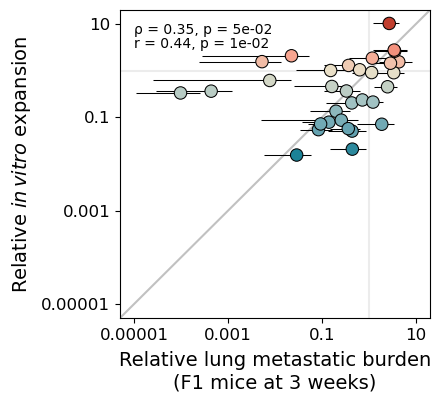

In [131]:
in_vitro_samples = metadata.loc[metadata['experiment'] == 'in vitro'].groupby('time point, d').apply(lambda df: df.index.tolist()) 
clIDs_ordered_in_vitro = ['AGGT', 'AGCA', 'CTTC', 'AGTC', 'ATCG', 'GAAG', 'CACT', 'ACCT', 'CCTT', 'CATG', 'GGAA', 'ACAC', 'GTTG', 'AGAG', 'TTGG', 'TCCA', 'CTGT', 'TTCC', 'CAGA', 'GCAT', 'CGTA', 'GGTT', 'ACGA', 'AAGG', 'GTAC', 'CGAT', 'GCTA', 'CAAC', 'TGAC', 'ATGC', 'ACTG', 'GTGA', 'CCAA'] # clIDs sorted by weighted avg expansion in vitro


clID__in_vitro_exp = {}
clID__in_vitro_exp_err = {}
for clID in clIDs_ordered_in_vitro:
     
    t = 3 # normalizing by the fraction at t = 3 days 
    norm = np.mean([read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in in_vitro_samples[t]])

    t = 23 # last time point
    y = [read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) / norm for sample_id in in_vitro_samples[t]]
    
    clID__in_vitro_exp[clID] = np.mean(y)
    clID__in_vitro_exp_err[clID] = [np.std(y), np.std(y)]
    
    
ax = comparison_scatter_plot([x for x in clIDs if x not in ['GATC', 'AGCA']],
                              clID__x=clID__in_vivo_exp_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_err,
                              clID__y=clID__in_vitro_exp, clID__yerr=clID__in_vitro_exp_err,
                              xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative ' + '$\it{in\,vitro}$' + ' expansion',
                              lims=[5e-6, 0.2e2], ticks=[1e-5, 1e-3, 1e-1, 1e1], labels=['0.00001', '0.001', '0.1', '10'])

#plt.savefig('../../../Figures/fig4/fig4_si_relative_in_vivo_exp_vs_relative_in_vitro_expansion.pdf', dpi=300, bbox_inches='tight')  

### Experiment vs experiment comparisons

In [132]:
# 3 week F1 mice:

what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples_1 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples_2 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

clID__in_vivo_exp_1, clID__in_vivo_exp_1_avg_relative_to_mean, clID__in_vivo_exp_1_err, clIDs_sorted_1 = bootstrap(samples_1)
clID__in_vivo_exp_2, clID__in_vivo_exp_2_avg_relative_to_mean, clID__in_vivo_exp_2_err, clIDs_sorted_2 = bootstrap(samples_2)

excluded: Spike-in 1
excluded: Panc02


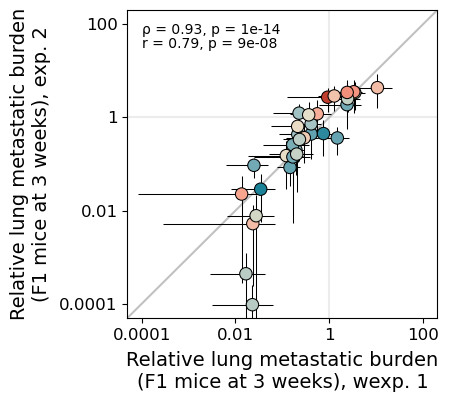

In [137]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                              clID__x=clID__in_vivo_exp_1_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_1_err,
                              clID__y=clID__in_vivo_exp_2_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_2_err,
                              xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks), exp. 1', ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks), exp. 2',
                              lims=[5e-5, 2e2], ticks=[1e-4, 1e-2, 1e0, 1e2], labels=['0.0001', '0.01', '1', '100'])

#plt.savefig('../../../Figures/fig4/fig4_si_exp_1vs_2_3w_f1_iv_lung.pdf', dpi=300, bbox_inches='tight')  

In [138]:
# 3 week Rag1 mice:

what = ['1', 20, 'Rag1-/-', 'intravenous', 'lung']
samples_1 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

what = ['2', 20, 'Rag1-/-', 'intravenous', 'lung']
samples_2 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

clID__in_vivo_exp_1, clID__in_vivo_exp_1_avg_relative_to_mean, clID__in_vivo_exp_1_err, clIDs_sorted_1 = bootstrap(samples_1)
clID__in_vivo_exp_2, clID__in_vivo_exp_2_avg_relative_to_mean, clID__in_vivo_exp_2_err, clIDs_sorted_2 = bootstrap(samples_2)

excluded: Spike-in 1
excluded: Panc02


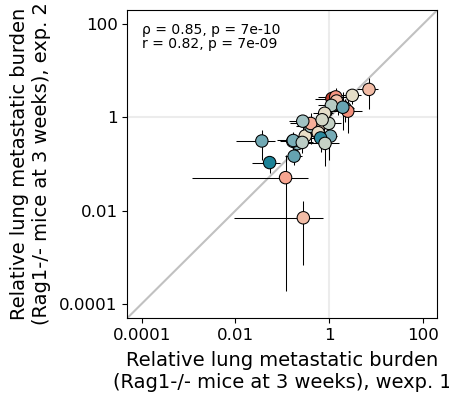

In [139]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                              clID__x=clID__in_vivo_exp_1_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_1_err,
                              clID__y=clID__in_vivo_exp_2_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_2_err,
                              xtitle='Relative lung metastatic burden\n(Rag1-/- mice at 3 weeks), exp. 1', ytitle='Relative lung metastatic burden\n(Rag1-/- mice at 3 weeks), exp. 2',
                              lims=[5e-5, 2e2], ticks=[1e-4, 1e-2, 1e0, 1e2], labels=['0.0001', '0.01', '1', '100'])

#plt.savefig('../../../Figures/fig4/fig4_si_exp_1vs_2_3w_rag1_iv_lung.pdf', dpi=300, bbox_inches='tight')  

In [161]:
what = ['1', 20, 'C57B6/129S F1', 'intraperitoneal', 'liver']
samples_1 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

what = ['2', 20, 'C57B6/129S F1', 'intrasplenic', 'liver']
samples_2 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

clID__in_vivo_exp_1, clID__in_vivo_exp_1_avg_relative_to_mean, clID__in_vivo_exp_1_err, clIDs_sorted_1 = bootstrap(samples_1)
clID__in_vivo_exp_2, clID__in_vivo_exp_2_avg_relative_to_mean, clID__in_vivo_exp_2_err, clIDs_sorted_2 = bootstrap(samples_2)

excluded: Spike-in 1
excluded: Panc02


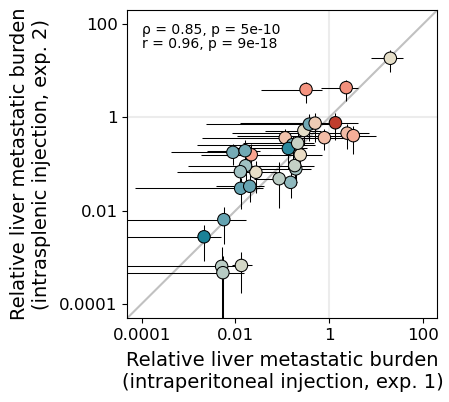

In [165]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                              clID__x=clID__in_vivo_exp_1_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_1_err,
                              clID__y=clID__in_vivo_exp_2_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_2_err,
                              xtitle='Relative liver metastatic burden\n(intraperitoneal injection, exp. 1)', ytitle='Relative liver metastatic burden\n(intrasplenic injection, exp. 2)',
                              lims=[5e-5, 2e2], ticks=[1e-4, 1e-2, 1e0, 1e2], labels=['0.0001', '0.01', '1', '100'])

#plt.savefig('../../../Figures/fig4/fig4_si_exp_1vs_2_liver.pdf', dpi=300, bbox_inches='tight')  

In [166]:
what = ['1', 20, 'C57B6/129S F1', 'intraperitoneal', 'pancreas']
samples_1 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

what = ['2', 20, 'C57B6/129S F1', 'intrapancreatic', 'pancreas']
samples_2 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

clID__in_vivo_exp_1, clID__in_vivo_exp_1_avg_relative_to_mean, clID__in_vivo_exp_1_err, clIDs_sorted_1 = bootstrap(samples_1)
clID__in_vivo_exp_2, clID__in_vivo_exp_2_avg_relative_to_mean, clID__in_vivo_exp_2_err, clIDs_sorted_2 = bootstrap(samples_2)

excluded: Spike-in 1
excluded: Panc02


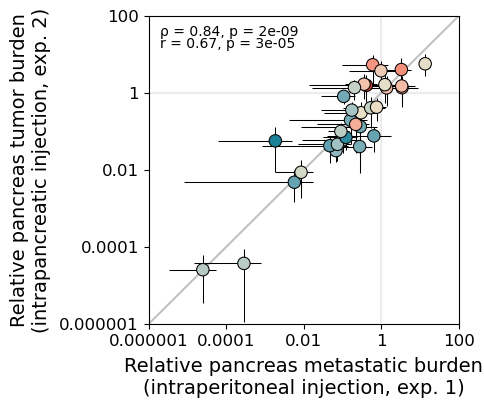

In [171]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                              clID__x=clID__in_vivo_exp_1_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_1_err,
                              clID__y=clID__in_vivo_exp_2_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_2_err,
                              xtitle='Relative pancreas metastatic burden\n(intraperitoneal injection, exp. 1)', ytitle='Relative pancreas tumor burden\n(intrapancreatic injection, exp. 2)',
                              lims=[1e-6, 1e2], ticks=[1e-6, 1e-4, 1e-2, 1e0, 1e2], labels=['0.000001', '0.0001', '0.01', '1', '100'])

#plt.savefig('../../../Figures/fig4/fig4_si_exp_1vs_2_pancreas.pdf', dpi=300, bbox_inches='tight')  